In [8]:
%pip install accelerate datasets evaluate rouge_score bert_score sacrebleu -q

Note: you may need to restart the kernel to use updated packages.


In [9]:
%pip install transformers==4.45.2 trl==0.11.3 -q

Note: you may need to restart the kernel to use updated packages.


In [10]:
# %%
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
from trl import DPOTrainer, DPOConfig
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import evaluate

In [11]:
# %%
# --- 2. Configuration ---
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # use GPU 1 only
MODEL_NAME = "gpt2"
DATASET_NAME = "HumanLLMs/Human-Like-DPO-Dataset"
DEVICE = "cuda:1" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4
EPOCHS = 1
LEARNING_RATE = 5e-6
MAX_LENGTH = 512
MAX_RESPONSE_LENGTH = 256
EXP_NAME = "dpo_gpt2" # Changed from ppo to dpo

BASE_DIR = f"runs/{EXP_NAME}"
CKPT_DIR = f"{BASE_DIR}/checkpoints"
LOG_DIR = f"{BASE_DIR}/logs"
PLOT_DIR = f"{BASE_DIR}/plots"

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

In [12]:
# %%
# --- 3. Load Model & Data ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
dataset = load_dataset(DATASET_NAME, split="train").train_test_split(test_size=0.2)

# Subsetting for efficiency
train_dataset = dataset["train"].select(range(min(len(dataset["train"]), 2048)))
eval_dataset = dataset["test"].select(range(min(len(dataset["test"]), 512)))

AcceleratorError: CUDA error: invalid device ordinal
GPU device may be out of range, do you have enough GPUs?
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# %%
# --- 4. Define Generative Metrics (Local) ---
bleu_metric = evaluate.load("sacrebleu")
rouge_metric = evaluate.load("rouge")
bertscore_metric = evaluate.load("bertscore")

def compute_generative_metrics(model, tokenizer, test_data):
    model.eval()
    predictions = []
    references = []
    
    print(f"Generating responses for {len(test_data)} samples...")
    for example in test_data:
        prompt = example["prompt"]
        target = example["chosen"]
        
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs, 
                max_new_tokens=64, 
                pad_token_id=tokenizer.eos_token_id,
                do_sample=True,
                temperature=0.7,
                repetition_penalty=1.2,
                no_repeat_ngram_size=2
            )
        
        pred_text = tokenizer.decode(outputs[0], skip_special_tokens=True)[len(prompt):].strip()
        
        # --- CRITICAL FIX START ---
        # BERTScore crashes on empty strings. If pred_text is empty, use a placeholder.
        if not pred_text or pred_text.strip() == "":
            pred_text = "." 
        # --- CRITICAL FIX END ---
        
        predictions.append(pred_text)
        references.append(target)

    # Compute Scores
    bleu = bleu_metric.compute(predictions=predictions, references=[[r] for r in references])
    rouge = rouge_metric.compute(predictions=predictions, references=references)
    
    # We add model_type="roberta-large" and use_fast_tokenizer=False to be extra safe
    bert = bertscore_metric.compute(
        predictions=predictions, 
        references=references, 
        lang="en", 
        model_type="roberta-large"
    )

    return {
        "bleu": bleu["score"],
        "rougeL": rouge["rougeL"],
        "bert_f1": np.mean(bert["f1"])
    }, predictions

In [ ]:
# %%
def compute_metrics(eval_output):
    """Calculates Accuracy/F1 based on DPO rewards (Chosen vs Rejected)."""
    # predictions can sometimes be a tuple (rewards, logits, etc.) 
    # and might be flattened or 2D depending on the TRL version.
    preds = eval_output.predictions
    
    # If preds is a tuple, we usually want the first element (the rewards/logits)
    if isinstance(preds, tuple):
        preds = preds[0]
        
    # If the array is 1D, TRL has flattened the [chosen_rewards, rejected_rewards]
    # We need to reshape it back to (N, 2)
    if len(preds.shape) == 1:
        # TRL often concatenates them, so we split them in half
        half = len(preds) // 2
        rewards_chosen = preds[:half]
        rewards_rejected = preds[half:]
    else:
        # Standard (N, 2) case
        rewards_chosen = preds[:, 0]
        rewards_rejected = preds[:, 1]
    
    # Accuracy: % of times chosen reward > rejected reward
    predictions = (rewards_chosen > rewards_rejected).astype(int)
    labels = np.ones_like(predictions) # Ground truth is always 1
    
    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary', zero_division=0
    )
    
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,   
        "reward_margin": (rewards_chosen - rewards_rejected).mean()
    }

In [ ]:
training_args = DPOConfig(
    output_dir=CKPT_DIR,
    report_to="tensorboard", 
    logging_dir=LOG_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    evaluation_strategy="steps",
    eval_steps=20,
    logging_steps=10,
    learning_rate=LEARNING_RATE,
    num_train_epochs=EPOCHS,
    remove_unused_columns=False,
    save_total_limit=2,
    # DPO specific arguments moved here from the trainer call
    beta=0.005,
    max_length=MAX_LENGTH,
    max_prompt_length=MAX_RESPONSE_LENGTH,
    max_steps=300,
    fp16=True if torch.cuda.is_available() else False,
    gradient_checkpointing=True, # Reduces VRAM usage for GPT-2
)

trainer = DPOTrainer(
    model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/transformers/training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Tokenizing eval dataset: 100%|██████████| 512/512 [00:00<00:00, 656.47 examples/s]
max_steps is given, it will override any value given in num_train_epochs


In [ ]:
# %%
# --- 7. Execution ---
print("Starting DPO training...")
trainer.train()

Starting DPO training...


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Reward Margin,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/rejected,Logps/chosen,Logits/rejected,Logits/chosen
20,0.595800,0.557497,0.375000,0.545455,1.000000,0.375000,-0.513250,0.078079,-0.216714,1.000000,0.294793,-566.661011,-575.019836,-110.597931,-111.962563
40,0.481800,0.437932,0.406250,0.577778,1.000000,0.406250,-0.498120,0.075127,-0.533646,1.000000,0.608772,-630.047424,-575.610352,-113.251862,-113.525459
60,0.353700,0.323421,0.406250,0.577778,1.000000,0.406250,-0.458758,0.015963,-0.979219,1.000000,0.995181,-719.161926,-587.443115,-115.627563,-115.186256
80,0.240500,0.208063,0.375000,0.545455,1.000000,0.375000,-0.444563,-0.166415,-1.730349,1.000000,1.563934,-869.388000,-623.918640,-118.173393,-117.588821
100,0.129700,0.100042,0.468750,0.638298,1.000000,0.468750,-0.394253,-0.637647,-3.220607,1.000000,2.582960,-1167.439697,-718.165161,-121.526108,-122.479347
120,0.044300,0.032049,0.437500,0.608696,1.000000,0.437500,-0.456333,-1.878193,-6.466932,1.000000,4.588739,-1816.704712,-966.274170,-123.966217,-129.532135
140,0.016700,0.011100,0.500000,0.666667,1.000000,0.500000,0.062032,-2.119519,-8.504884,1.000000,6.385366,-2224.295166,-1014.539429,-111.649742,-119.005150
160,0.003900,0.004008,0.468750,0.638298,1.000000,0.468750,0.171205,-2.537663,-11.217677,1.000000,8.680013,-2766.853760,-1098.168457,-95.903236,-109.815285
180,0.001600,0.001598,0.531250,0.693878,1.000000,0.531250,0.064333,-2.404977,-13.318796,1.000000,10.913821,-3187.077881,-1071.630981,-89.487541,-105.108406
200,0.000100,0.000654,0.468750,0.638298,1.000000,0.468750,-0.038283,-2.570045,-16.660278,1.000000,14.090234,-3855.373779,-1104.644775,-86.243759,-102.490395


TrainOutput(global_step=300, training_loss=0.13579024923112987, metrics={'train_runtime': 1263.7823, 'train_samples_per_second': 1.899, 'train_steps_per_second': 0.237, 'total_flos': 0.0, 'train_loss': 0.13579024923112987, 'epoch': 1.171875})

In [ ]:
# %%
# --- 8. Final Evaluation & Local Plotting ---
print("\n--- Running Final Generative Evaluation ---")
gen_metrics, preds = compute_generative_metrics(model, tokenizer, eval_dataset)

# Save Generative Metrics to a local file
with open(f"{BASE_DIR}/final_metrics.txt", "w") as f:
    for k, v in gen_metrics.items():
        f.write(f"{k.upper()}: {v:.4f}\n")
        print(f"{k.upper()}: {v:.4f}")


--- Running Final Generative Evaluation ---
Generating responses for 512 samples...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BLEU: 0.0014
ROUGEL: 0.0480
BERT_F1: 0.7892


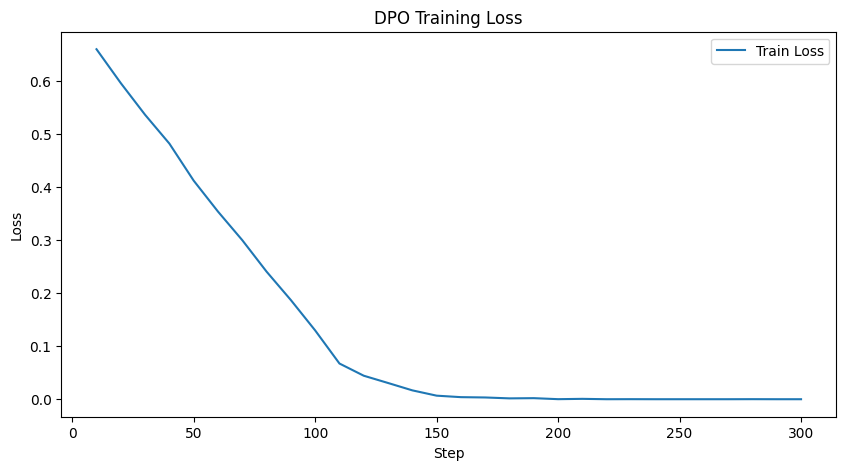

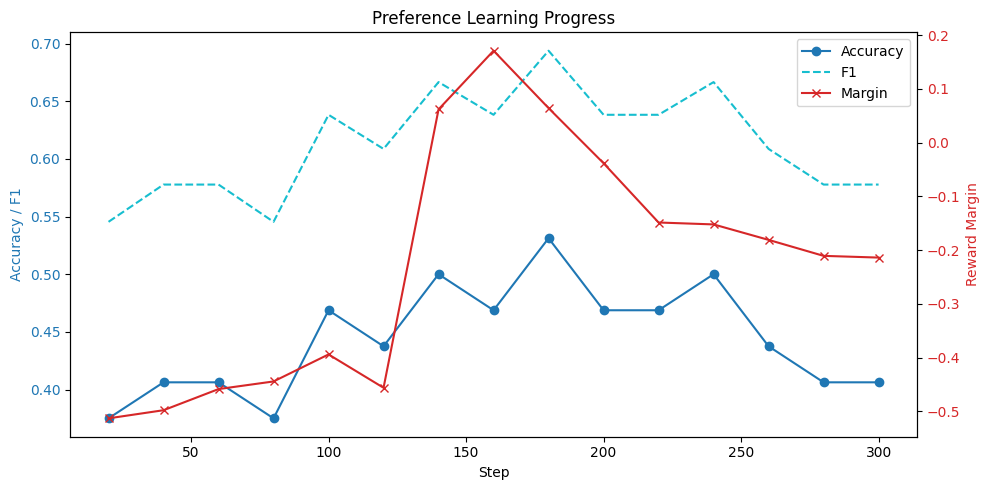

In [ ]:
# %%
def plot_local_results(trainer):
    """Parses trainer logs and saves plots to PLOT_DIR."""
    history = pd.DataFrame(trainer.state.log_history)
    
    # 1. Plot Loss
    plt.figure(figsize=(10, 5))
    train_loss = history[history['loss'].notna()]
    plt.plot(train_loss['step'], train_loss['loss'], label='Train Loss')
    plt.title("DPO Training Loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(f"{PLOT_DIR}/loss_curve.png")
    plt.show()

    # 2. Plot Reward Accuracy & Margin
    eval_logs = history[history['eval_accuracy'].notna()]
    if not eval_logs.empty:
        fig, ax1 = plt.subplots(figsize=(10, 5))
        
        ax1.set_xlabel('Step')
        ax1.set_ylabel('Accuracy / F1', color='tab:blue')
        l1, = ax1.plot(eval_logs['step'], eval_logs['eval_accuracy'], label='Accuracy', color='tab:blue', marker='o')
        l2, = ax1.plot(eval_logs['step'], eval_logs['eval_f1'], label='F1', color='tab:cyan', linestyle='--')
        ax1.tick_params(axis='y', labelcolor='tab:blue')

        ax2 = ax1.twinx()
        ax2.set_ylabel('Reward Margin', color='tab:red')
        l3, = ax2.plot(eval_logs['step'], eval_logs['eval_reward_margin'], label='Margin', color='tab:red', marker='x')
        ax2.tick_params(axis='y', labelcolor='tab:red')

        # Combine legends from both axes
        lines = [l1, l2, l3]
        labels = [line.get_label() for line in lines]
        ax1.legend(lines, labels, loc='best')

        plt.title("Preference Learning Progress")
        fig.tight_layout()
        plt.savefig(f"{PLOT_DIR}/metrics_curve.png")
        plt.show()

plot_local_results(trainer)

In [ ]:
# Save side-by-side comparison to CSV for local review
comparison_df = pd.DataFrame({
    "Prompt": [eval_dataset[i]["prompt"] for i in range(len(preds))],
    "Target (Human)": [eval_dataset[i]["chosen"] for i in range(len(preds))],
    "Model Output": preds
})
comparison_df.to_csv(f"{BASE_DIR}/generations_comparison.csv", index=False)
print(f"Evaluation complete. Results saved to {BASE_DIR}")

Evaluation complete. Results saved to runs/dpo_human_alignment


In [ ]:
formatted_prompt = f"Question: How are you?\n\nAnswer: "
        
inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)

# 2. Generation with Diversity Constraints (prevents model collapse)
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2,      # Crucial to stop loops
        no_repeat_ngram_size=2,       # Prevents phrase stuttering
        pad_token_id=tokenizer.eos_token_id
    )

# 3. Decode and Clean Output
full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
# Extract only the model's generated part (after the prompt)
response = full_text[len(formatted_prompt):].strip()

print(f"{formatted_prompt}{response}")

Question: How are you?

Answer: ive been doing that for a while! I'm like… yeah, it's funny how much stuff comes out of your mouth all the time. But then something happens and…" "Oh no!" You think about my mom telling me to go get some pumpkin muffins after school." Then there were those things where she was
